In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pycot.reports import CommitmentsOfTraders
import seaborn as sns

In [2]:
# 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("pastel")

03-Apr-25 22:08:35 - Extracting data for the traders_in_financial_futures_fut report type


E-MINI S&P 500 - CHICAGO MERCANTILE EXCHANGE


/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/pycot/reports.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


                                           Contract Name  Open Interest  \
Date                                                                      
2022-02-08  E-MINI S&P 500 - CHICAGO MERCANTILE EXCHANGE      2229911.0   
2022-02-15  E-MINI S&P 500 - CHICAGO MERCANTILE EXCHANGE      2270263.0   
2022-02-22  E-MINI S&P 500 - CHICAGO MERCANTILE EXCHANGE      2374165.0   
2022-03-01  E-MINI S&P 500 - CHICAGO MERCANTILE EXCHANGE      2387492.0   
2022-03-08  E-MINI S&P 500 - CHICAGO MERCANTILE EXCHANGE      2435543.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2022-02-08           1020324.0            -461827.0              282160.0   
2022-02-15            993607.0            -476417.0              292399.0   
2022-02-22           1012399.0            -514919.0              324127.0   
2022-03-01            998880.0            -535235.0              299237.0   
2022-03-08  

<Figure size 720x576 with 0 Axes>

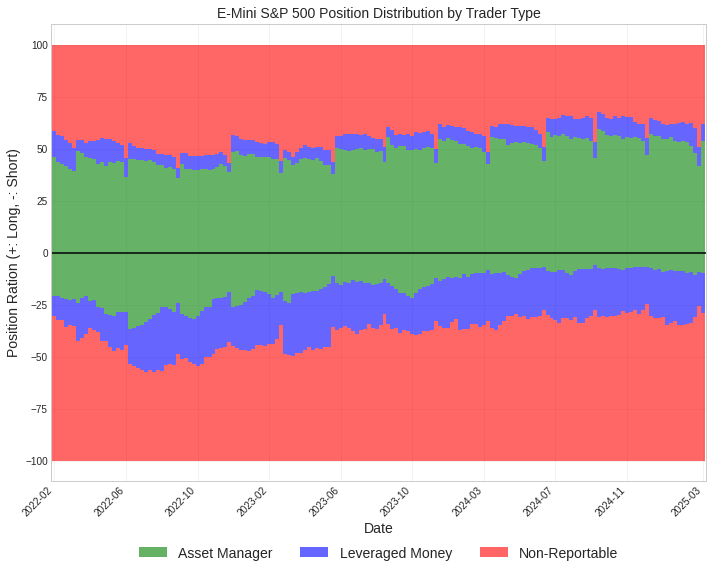

In [11]:
# 필요한 COT 데이터 가져오기
cot = CommitmentsOfTraders(report_type='traders_in_financial_futures_fut')

# 모든 contract에 대해서 계산하기
available_contracts = ["E-MINI S&P 500 - CHICAGO MERCANTILE EXCHANGE"]

for contract in available_contracts:
    print(contract)
    
    # report 가져오기 
    emini_data = cot.report(contract).sort_index()

    # 데이터 구조 확인
    print(emini_data.head()) 
    
    # 데이터 전처리
    # 1. 자산 운용사 (Asset Manager)
    # 2. 대형 투기자 (Leveraged Money - 헤지펀드, 대형 투기자로 분류됨)
    # 3. 비-보고 대상 (Non-Reportable - 직접 계산 필요)

    # 비-보고 대상 계산 (전체 오픈 인터레스트에서 보고된 포지션을 뺀 값)
    emini_data['Non-Reportable Long, % of OI'] = 100 - (emini_data['Asset Manager Long, % of OI'] + emini_data['Leveraged Money Long, % of OI'])
    emini_data['Non-Reportable Short, % of OI'] = 100 - (emini_data['Asset Manager Short, % of OI'] + emini_data['Leveraged Money Short, % of OI'])
    
    # 추가 분석: 세 그룹의 Long short position 비교
    plt.figure(figsize=(10, 8))
    
    # 스택 바 차트를 위한 데이터 준비
    # Long 포지션 (양수 값)
    long_data = pd.DataFrame({
        'Asset Manager': emini_data['Asset Manager Long, % of OI'],
        'Leveraged Money': emini_data['Leveraged Money Long, % of OI'],
        'Non-Reportable': emini_data['Non-Reportable Long, % of OI']
    }, index=emini_data.index)
    
    # Short 포지션 (음수 값으로 변환)
    short_data = pd.DataFrame({
        'Asset Manager': -emini_data['Asset Manager Short, % of OI'],
        'Leveraged Money': -emini_data['Leveraged Money Short, % of OI'],
        'Non-Reportable': -emini_data['Non-Reportable Short, % of OI']
    }, index=emini_data.index)
    
    # 스택 바 차트 그리기
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Long 포지션 (위쪽)
    long_data.plot(kind='bar', stacked=True, ax=ax, width=1, 
                  color=['green', 'blue', 'red'], alpha=0.6)
    
    # Short 포지션 (아래쪽)
    short_data.plot(kind='bar', stacked=True, ax=ax, width=1, 
                   color=['green', 'blue', 'red'], alpha=0.6)
    
    # 차트 스타일링
    fontsize = 14
    plt.axhline(y=0, color='k', linestyle='-', alpha=1)
    plt.title('E-Mini S&P 500 Position Distribution by Trader Type', fontsize=fontsize)
    plt.xlabel('Date', fontsize=fontsize)
    plt.ylabel('Position Ration (+: Long, -: Short)', fontsize=fontsize)
    plt.grid(True, alpha=0.3)
    
    # x축 날짜 포맷 설정
    tick_indices = np.linspace(0, len(emini_data.index) - 1, min(10, len(emini_data.index))).astype(int)
    plt.xticks(tick_indices, [emini_data.index[i].strftime('%Y-%m') for i in tick_indices], rotation=45, ha='right')
    
    # 범례 설정
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:3], ['Asset Manager', 'Leveraged Money', 'Non-Reportable'], 
              loc='lower center', bbox_to_anchor=(0.5, -0.2), fontsize=fontsize, ncol=3)
    
    plt.tight_layout()
    plt.show()

03-Apr-25 20:54:13 - Extracting data for the traders_in_financial_futures_fut report type
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/pycot/reports.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


1-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE
                                         Contract Name  Open Interest  \
Date                                                                    
2022-02-01  1-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE       307461.0   
2022-01-25  1-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE       333154.0   
2022-01-18  1-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE       327742.0   
2022-01-11  1-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE       296422.0   
2022-01-04  1-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE       182896.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2022-02-01             28228.0              -2606.0               55719.0   
2022-01-25             27925.0              -4361.0               52532.0   
2022-01-18             29219.0                -59.0               44608.0   
2022-01-11             29880.0                 -0.0         

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

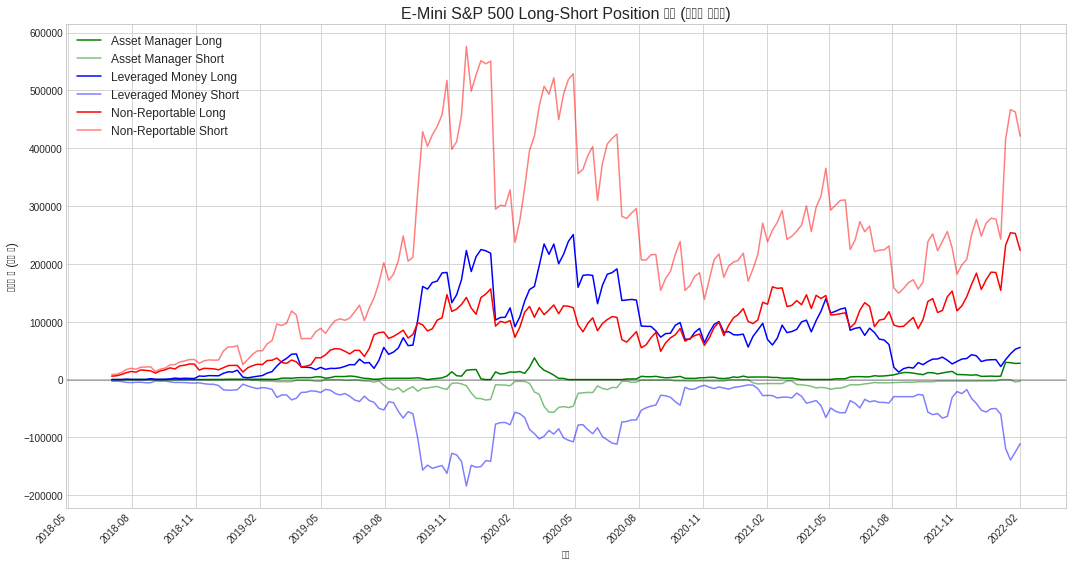

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

10 YEAR DELIVERABLE IR - CHICAGO BOARD OF TRADE
                                              Contract Name  Open Interest  \
Date                                                                         
2022-03-08  10 YEAR DELIVERABLE IR - CHICAGO BOARD OF TRADE        66444.0   
2022-03-01  10 YEAR DELIVERABLE IR - CHICAGO BOARD OF TRADE        75215.0   
2022-02-22  10 YEAR DELIVERABLE IR - CHICAGO BOARD OF TRADE        75443.0   
2022-02-15  10 YEAR DELIVERABLE IR - CHICAGO BOARD OF TRADE        76187.0   
2022-02-08  10 YEAR DELIVERABLE IR - CHICAGO BOARD OF TRADE        73926.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2022-03-08                 0.0              -1693.0                6492.0   
2022-03-01                 0.0              -1693.0                6491.0   
2022-02-22                 0.0              -1681.0                6311.0   
2022-02-15          

/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: U

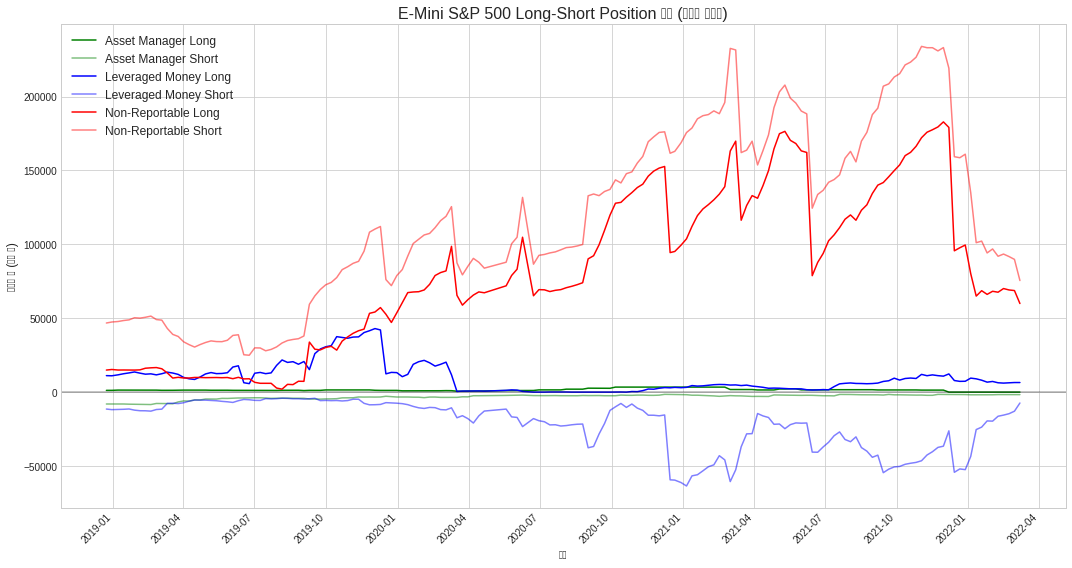

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

10 YEAR DELIVERABLE IR SWAP - CHICAGO BOARD OF TRADE
                                                Contract Name  Open Interest  \
Date                                                                           
2018-12-18  10 YEAR DELIVERABLE IR SWAP - CHICAGO BOARD OF...        25640.0   
2018-12-11  10 YEAR DELIVERABLE IR SWAP - CHICAGO BOARD OF...        28630.0   
2018-12-04  10 YEAR DELIVERABLE IR SWAP - CHICAGO BOARD OF...        29848.0   
2018-11-27  10 YEAR DELIVERABLE IR SWAP - CHICAGO BOARD OF...        30321.0   
2018-11-20  10 YEAR DELIVERABLE IR SWAP - CHICAGO BOARD OF...        29688.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2018-12-18              1177.0              -7892.0               13276.0   
2018-12-11              1175.0              -8076.0               16678.0   
2018-12-04              1243.0              -8017.0               17323.0   
2

<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N

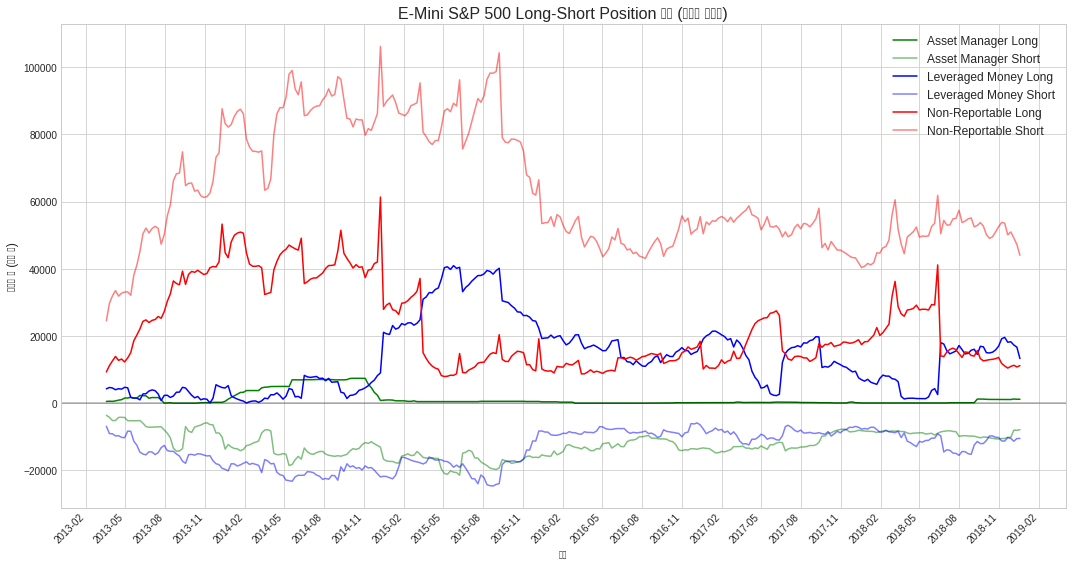

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

10 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE
                                              Contract Name  Open Interest  \
Date                                                                         
2025-03-25  10 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE       117841.0   
2025-03-18  10 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE       115410.0   
2025-03-11  10 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE       113573.0   
2025-03-04  10 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE       114711.0   
2025-02-25  10 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE       106536.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2025-03-25               365.0                 -0.0                6403.0   
2025-03-18               365.0                 -0.0                6381.0   
2025-03-11               365.0                 -0.0                6691.0   
2025-03-04          

<ipython-input-3-789585640295>:50: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  plt.tight_layout()
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  fig.canvas.

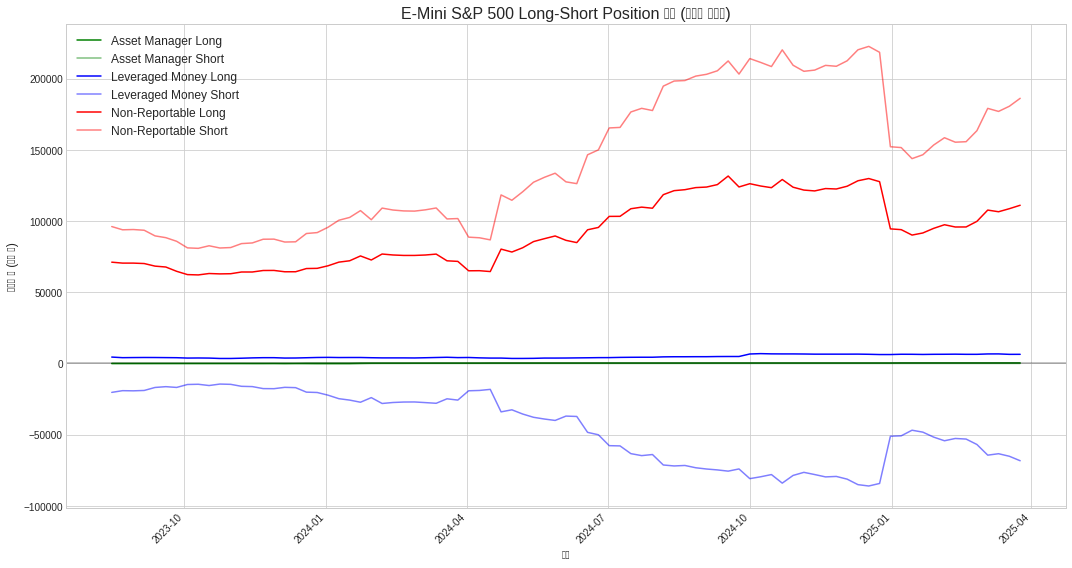

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

10 YEAR ERIS SWAP  - CHICAGO BOARD OF TRADE
                                          Contract Name  Open Interest  \
Date                                                                     
2019-12-03  10 YEAR ERIS SWAP  - CHICAGO BOARD OF TRADE        90309.0   
2019-08-27  10 YEAR ERIS SWAP  - CHICAGO BOARD OF TRADE       112844.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2019-12-03               720.0                 -0.0                7203.0   
2019-08-27               630.0                 -0.0                7882.0   

            Leveraged Money Short  Open Interest, Change  \
Date                                                       
2019-12-03               -45268.0                    NaN   
2019-08-27               -55272.0                    NaN   

            Asset Manager Long, Change  Asset Manager Short, Change  \
Date                                  

/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: U

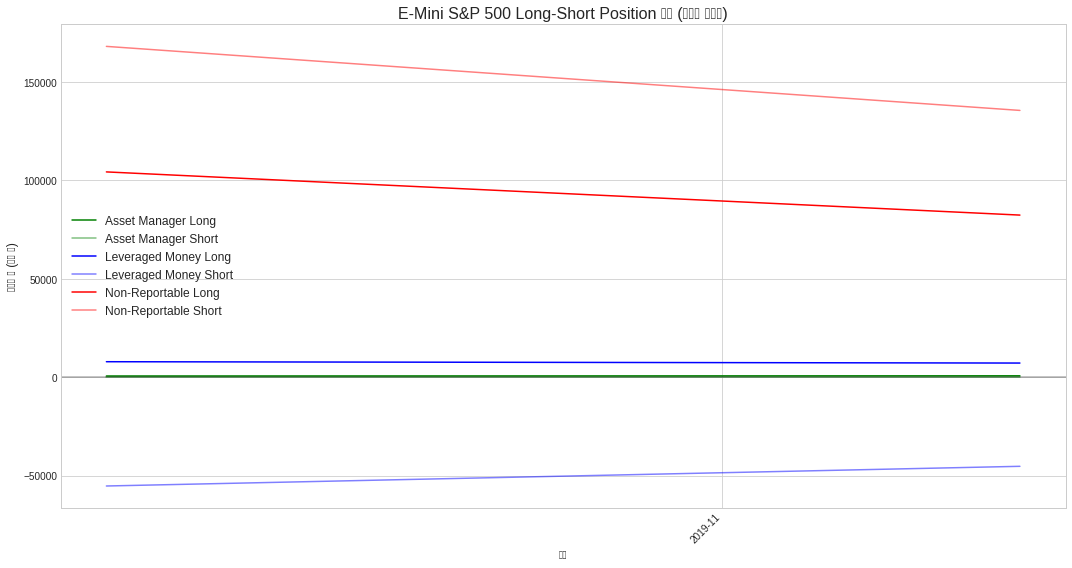

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

10-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF TRADE
                                                Contract Name  Open Interest  \
Date                                                                           
2022-02-01  10-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF...      3932501.0   
2022-01-25  10-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF...      3750564.0   
2022-01-18  10-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF...      3890037.0   
2022-01-11  10-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF...      3809163.0   
2022-01-04  10-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF...      3875093.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2022-02-01           1613868.0           -1368485.0              888568.0   
2022-01-25           1598943.0           -1384894.0              753382.0   
2022-01-18           1646386.0           -1413808.0              762150.0   
2

<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N

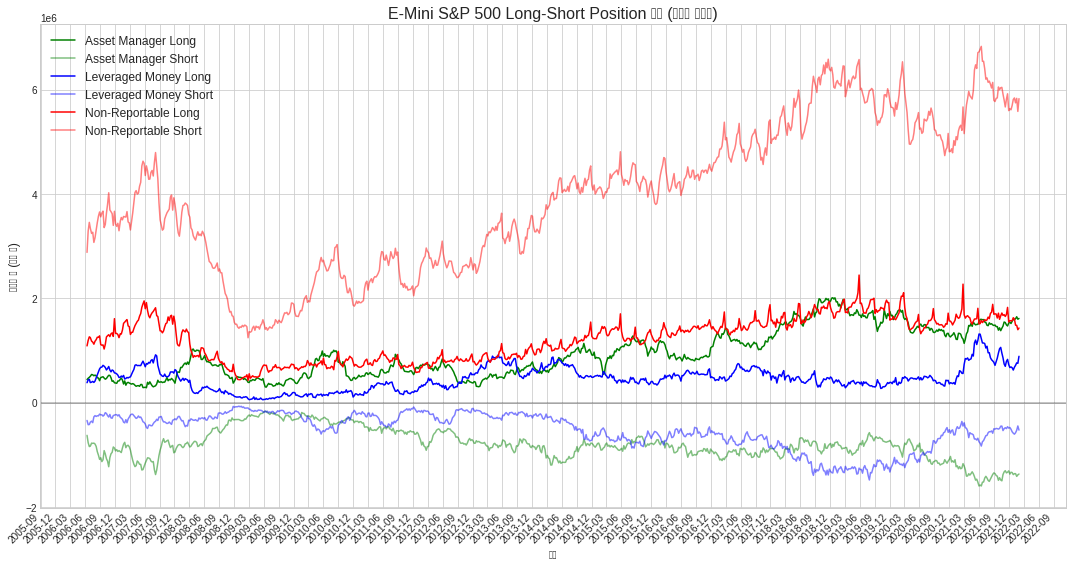

1K SHIB - LMX LABS LLC
                     Contract Name  Open Interest  Asset Manager Long  \
Date                                                                    
2025-01-28  1K SHIB - LMX LABS LLC         1518.0                 0.0   
2025-01-21  1K SHIB - LMX LABS LLC         1748.0                 0.0   
2025-01-14  1K SHIB - LMX LABS LLC         1559.0                 0.0   
2024-12-24  1K SHIB - LMX LABS LLC         2406.0                 0.0   
2024-12-17  1K SHIB - LMX LABS LLC         2926.0                 0.0   

            Asset Manager Short  Leveraged Money Long  Leveraged Money Short  \
Date                                                                           
2025-01-28                 -0.0                   0.0                -1217.0   
2025-01-21                 -0.0                   0.0                -1457.0   
2025-01-14                 -0.0                   0.0                -1290.0   
2024-12-24                 -0.0                   0.0            

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

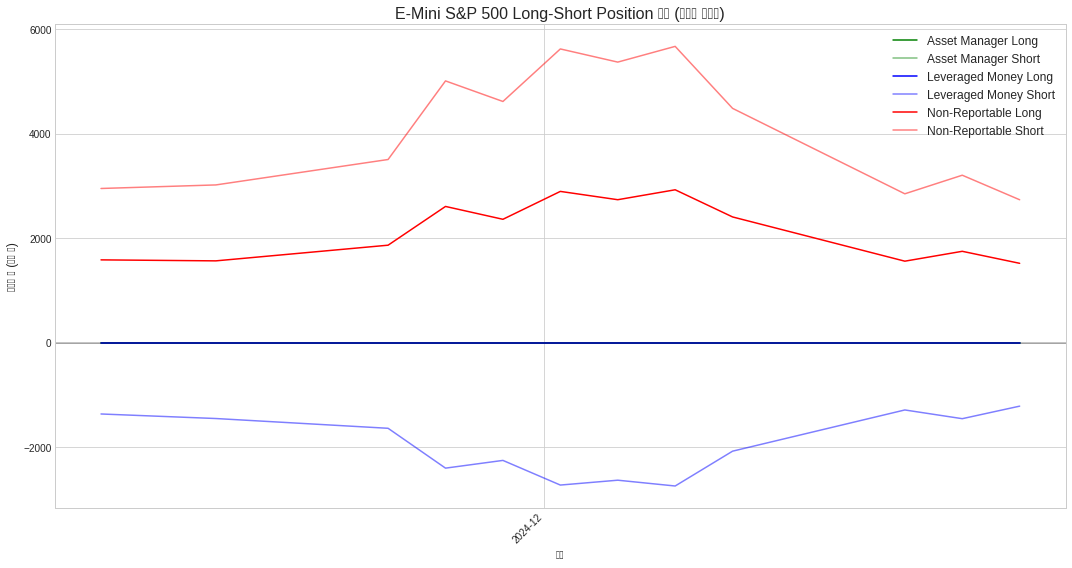

2 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE
                                             Contract Name  Open Interest  \
Date                                                                        
2025-03-25  2 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE        28557.0   
2025-03-18  2 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE        29329.0   
2025-03-11  2 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE        32335.0   
2025-03-04  2 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE        33823.0   
2025-02-25  2 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE        33206.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2025-03-25               157.0                -60.0               18816.0   
2025-03-18               157.0                -60.0               18805.0   
2025-03-11               157.0                -60.0               20719.0   
2025-03-04               157

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

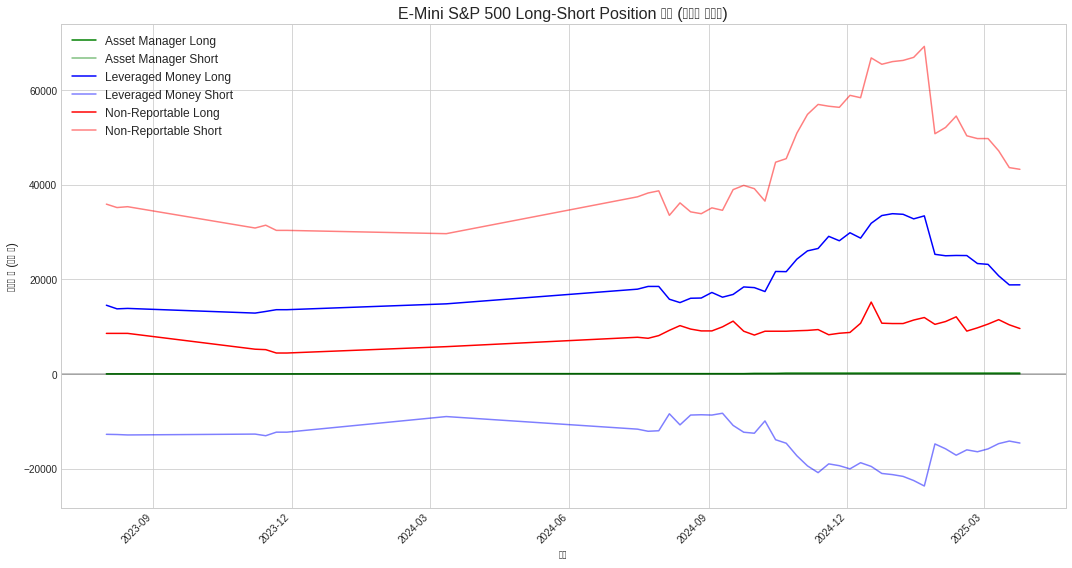

2 YEAR ERIS SWAP - CHICAGO BOARD OF TRADE
                                        Contract Name  Open Interest  \
Date                                                                   
2022-05-31  2 YEAR ERIS SWAP - CHICAGO BOARD OF TRADE       161471.0   
2022-05-24  2 YEAR ERIS SWAP - CHICAGO BOARD OF TRADE       162168.0   
2022-05-17  2 YEAR ERIS SWAP - CHICAGO BOARD OF TRADE       153519.0   
2022-05-10  2 YEAR ERIS SWAP - CHICAGO BOARD OF TRADE       151991.0   
2022-05-03  2 YEAR ERIS SWAP - CHICAGO BOARD OF TRADE       151343.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2022-05-31                 0.0                 -0.0               58656.0   
2022-05-24                 0.0                 -0.0               57754.0   
2022-05-17                 0.0                 -0.0               49105.0   
2022-05-10                 0.0                 -0.0               49

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

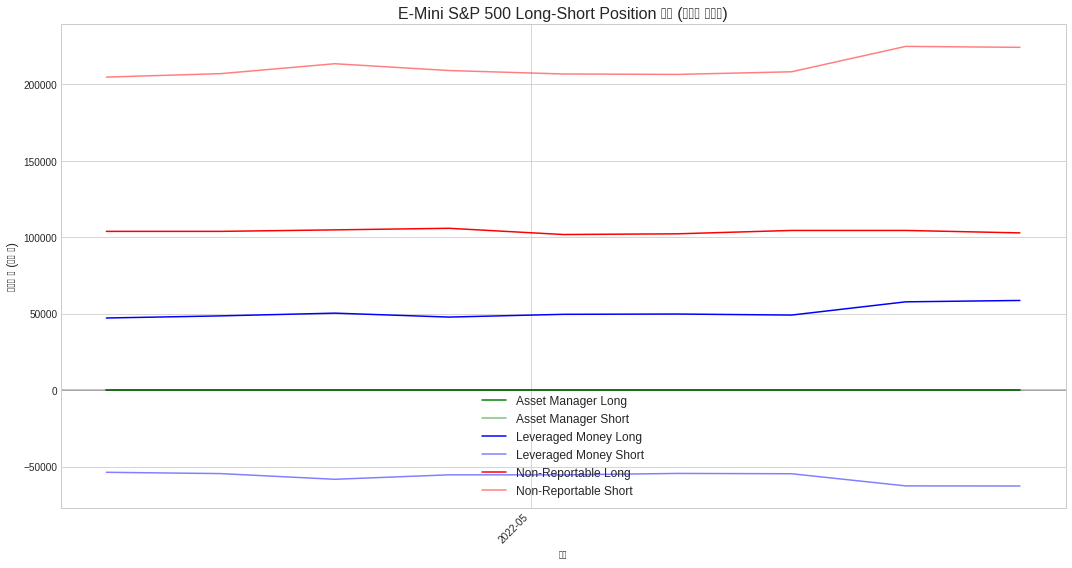

2-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF TRADE
                                                Contract Name  Open Interest  \
Date                                                                           
2022-02-01  2-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF ...      2270248.0   
2022-01-25  2-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF ...      2112007.0   
2022-01-18  2-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF ...      2107849.0   
2022-01-11  2-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF ...      2017016.0   
2022-01-04  2-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF ...      1947598.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2022-02-01            803547.0            -674758.0              626389.0   
2022-01-25            798806.0            -695757.0              489026.0   
2022-01-18            769566.0            -661191.0              536093.0   
20

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

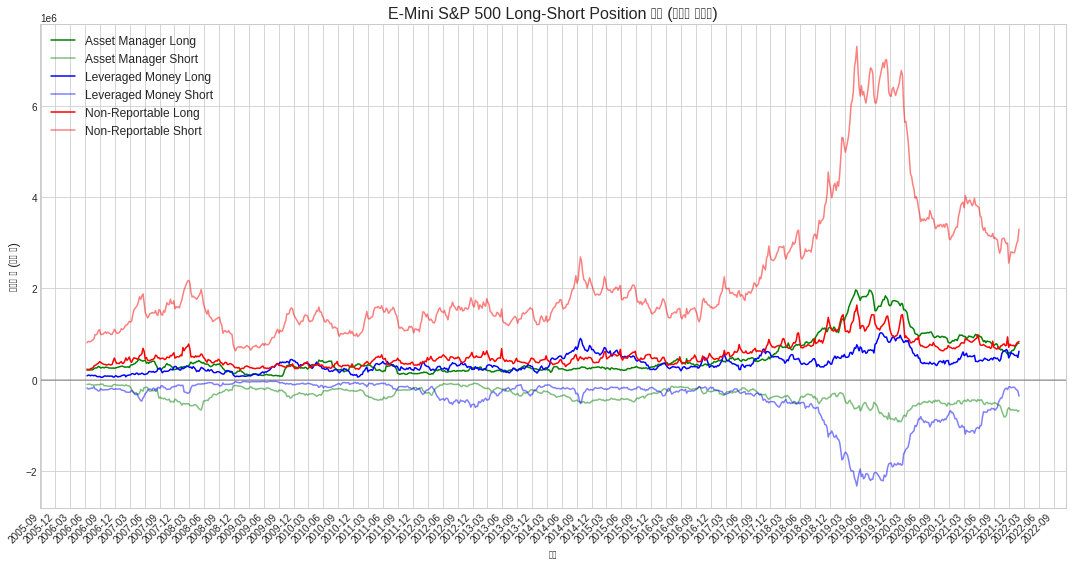

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

3-MO. EUROYEN TIBOR - CHICAGO MERCANTILE EXCHANGE
                                                Contract Name  Open Interest  \
Date                                                                           
2009-03-10  3-MO. EUROYEN TIBOR - CHICAGO MERCANTILE EXCHANGE        11534.0   
2009-03-03  3-MO. EUROYEN TIBOR - CHICAGO MERCANTILE EXCHANGE         9915.0   
2008-12-09  3-MO. EUROYEN TIBOR - CHICAGO MERCANTILE EXCHANGE        11961.0   
2008-12-02  3-MO. EUROYEN TIBOR - CHICAGO MERCANTILE EXCHANGE        10726.0   
2008-11-25  3-MO. EUROYEN TIBOR - CHICAGO MERCANTILE EXCHANGE        10418.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2009-03-10                 0.0                 -0.0                   0.0   
2009-03-03                 0.0                 -0.0                   0.0   
2008-12-09                 0.0                 -0.0                 690.0   
2008

<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N

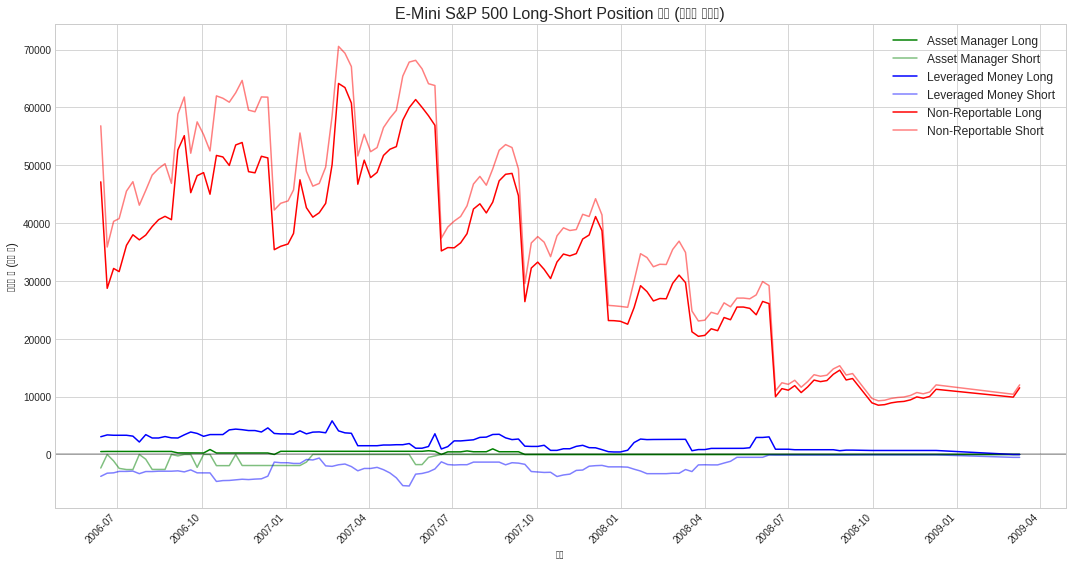

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

3-MONTH EURODOLLARS - CHICAGO MERCANTILE EXCHANGE
                                                Contract Name  Open Interest  \
Date                                                                           
2022-02-01  3-MONTH EURODOLLARS - CHICAGO MERCANTILE EXCHANGE     11123574.0   
2022-01-25  3-MONTH EURODOLLARS - CHICAGO MERCANTILE EXCHANGE     11211597.0   
2022-01-18  3-MONTH EURODOLLARS - CHICAGO MERCANTILE EXCHANGE     11026173.0   
2022-01-11  3-MONTH EURODOLLARS - CHICAGO MERCANTILE EXCHANGE     11368090.0   
2022-01-04  3-MONTH EURODOLLARS - CHICAGO MERCANTILE EXCHANGE     11248084.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2022-02-01           1098546.0           -1218332.0             1056320.0   
2022-01-25           1056996.0           -1312049.0             1302266.0   
2022-01-18           1054582.0           -1334640.0             1315833.0   
2022

<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N

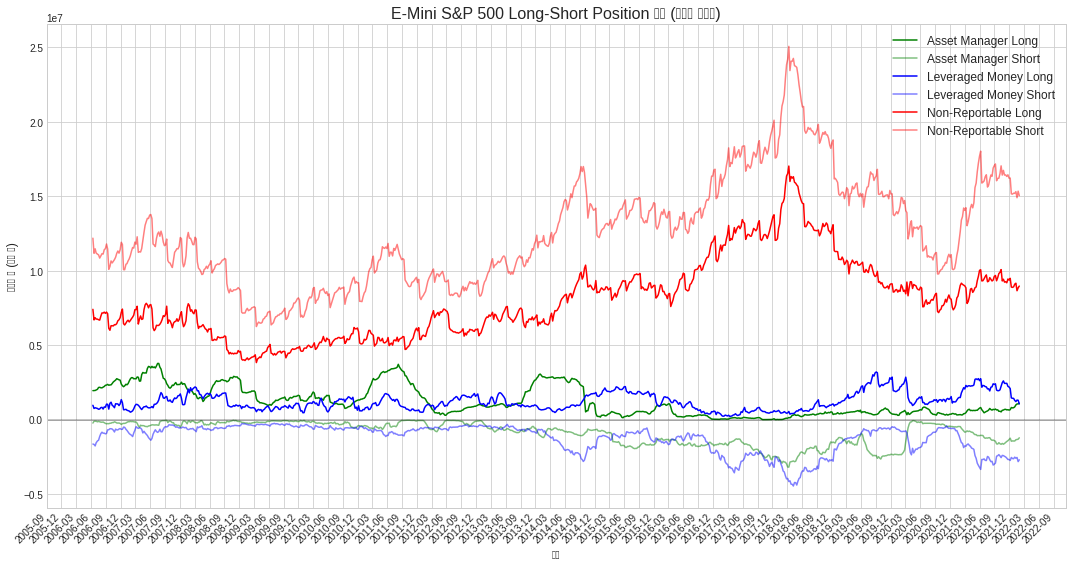

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

3-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE
                                         Contract Name  Open Interest  \
Date                                                                    
2022-02-01  3-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE      2711352.0   
2022-01-25  3-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE      2388241.0   
2022-01-18  3-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE      2085007.0   
2022-01-11  3-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE      1819049.0   
2022-01-04  3-MONTH SOFR - CHICAGO MERCANTILE EXCHANGE      1695730.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2022-02-01             46098.0            -110520.0              287615.0   
2022-01-25             41724.0            -170221.0              198245.0   
2022-01-18             22426.0            -175441.0              155691.0   
2022-01-11             21123.0            -166324.0         

<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N

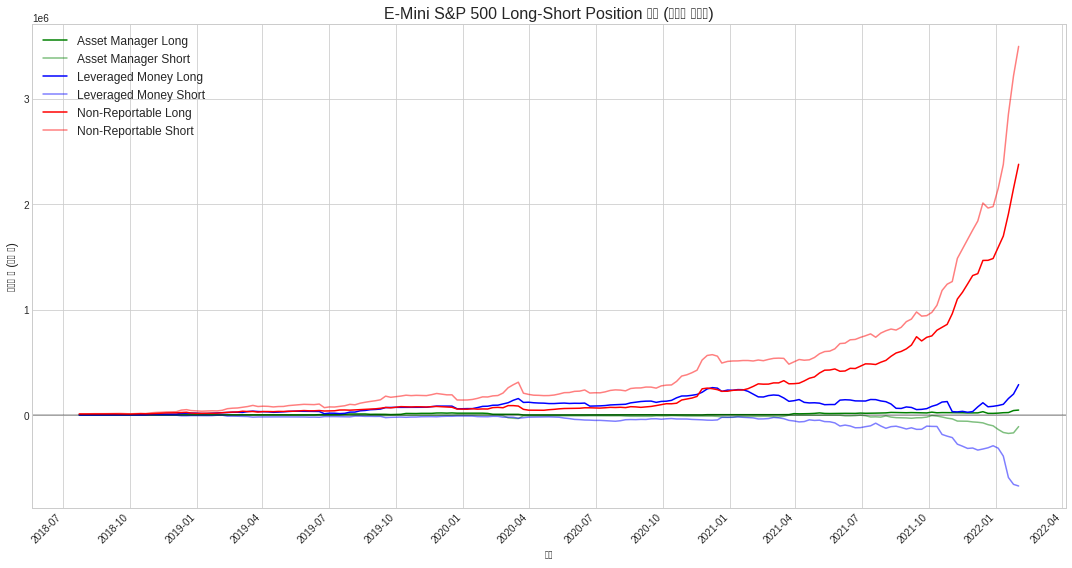

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

30-DAY FEDERAL FUNDS - CHICAGO BOARD OF TRADE
                                            Contract Name  Open Interest  \
Date                                                                       
2022-02-01  30-DAY FEDERAL FUNDS - CHICAGO BOARD OF TRADE      1705691.0   
2022-01-25  30-DAY FEDERAL FUNDS - CHICAGO BOARD OF TRADE      1790901.0   
2022-01-18  30-DAY FEDERAL FUNDS - CHICAGO BOARD OF TRADE      1708635.0   
2022-01-11  30-DAY FEDERAL FUNDS - CHICAGO BOARD OF TRADE      1534232.0   
2022-01-04  30-DAY FEDERAL FUNDS - CHICAGO BOARD OF TRADE      1306160.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2022-02-01             19917.0             -28886.0              215294.0   
2022-01-25             16800.0             -16808.0              191087.0   
2022-01-18              5483.0             -18177.0              189204.0   
2022-01-11             17543.0      

<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N

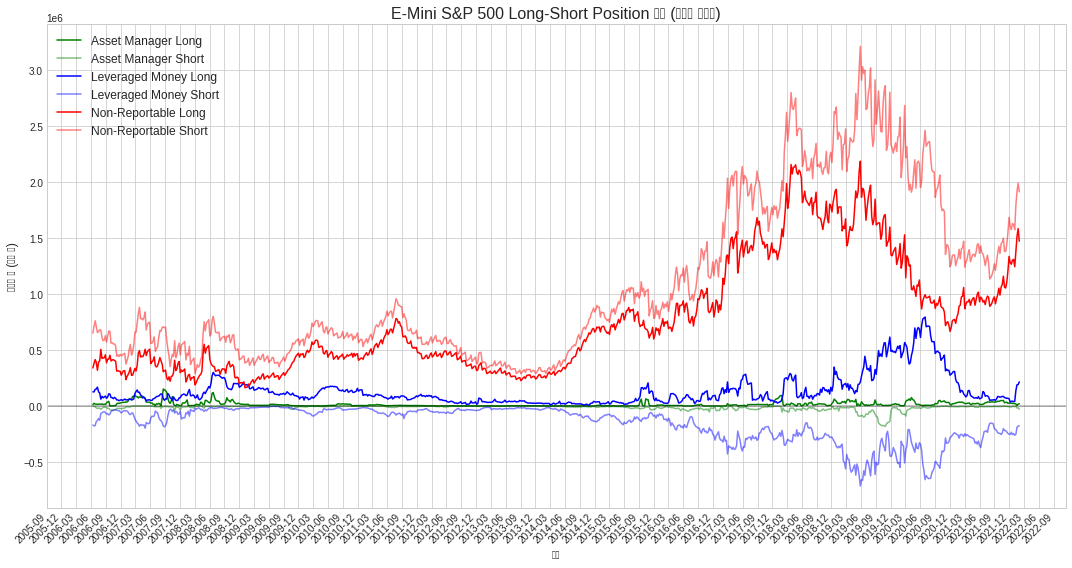

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

5 YEAR DELIVERABLE IR - CHICAGO BOARD OF TRADE
                                             Contract Name  Open Interest  \
Date                                                                        
2020-03-03  5 YEAR DELIVERABLE IR - CHICAGO BOARD OF TRADE        44315.0   
2020-02-25  5 YEAR DELIVERABLE IR - CHICAGO BOARD OF TRADE        34313.0   
2020-02-18  5 YEAR DELIVERABLE IR - CHICAGO BOARD OF TRADE        32632.0   
2020-02-11  5 YEAR DELIVERABLE IR - CHICAGO BOARD OF TRADE        32227.0   
2020-02-04  5 YEAR DELIVERABLE IR - CHICAGO BOARD OF TRADE        28946.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2020-03-03              1541.0               -370.0               16087.0   
2020-02-25              1293.0               -475.0               16527.0   
2020-02-18              1293.0               -593.0               15765.0   
2020-02-11              1293

<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N

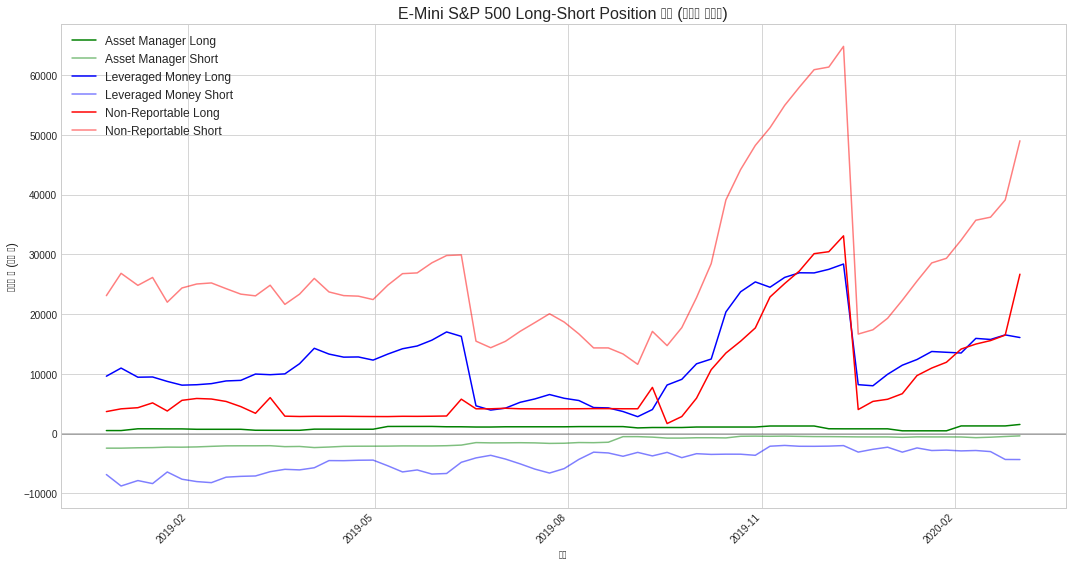

5 YEAR DELIVERABLE IR SWAP - CHICAGO BOARD OF TRADE
                                                Contract Name  Open Interest  \
Date                                                                           
2018-12-18  5 YEAR DELIVERABLE IR SWAP - CHICAGO BOARD OF ...        13383.0   
2018-12-11  5 YEAR DELIVERABLE IR SWAP - CHICAGO BOARD OF ...        17609.0   
2018-12-04  5 YEAR DELIVERABLE IR SWAP - CHICAGO BOARD OF ...        18529.0   
2018-11-27  5 YEAR DELIVERABLE IR SWAP - CHICAGO BOARD OF ...        16926.0   
2018-11-20  5 YEAR DELIVERABLE IR SWAP - CHICAGO BOARD OF ...        16497.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2018-12-18               525.0              -2423.0                9037.0   
2018-12-11               525.0              -2606.0               11030.0   
2018-12-04              1089.0              -2623.0               12497.0   
20

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

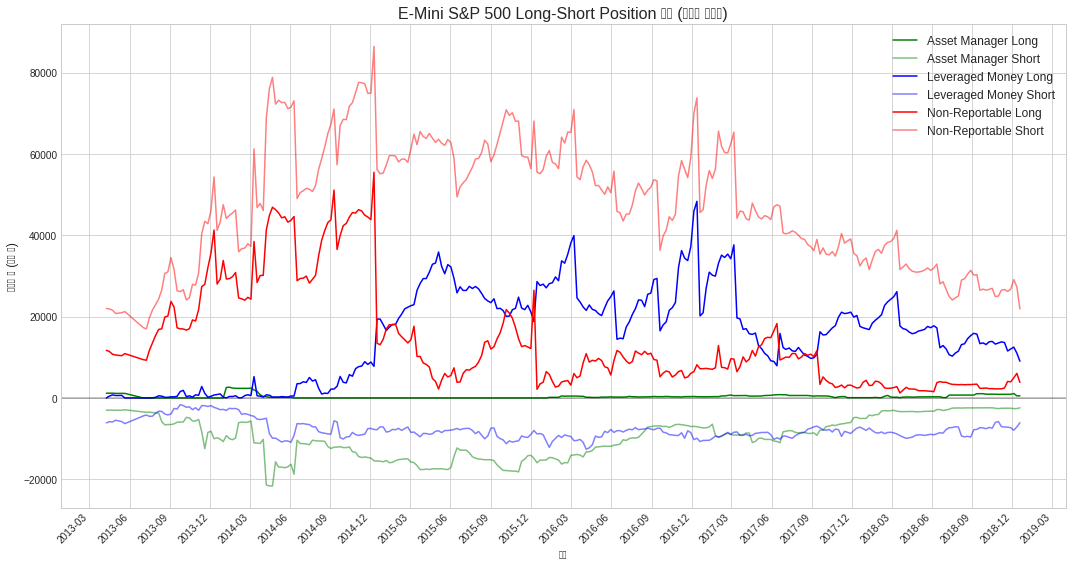

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

5 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE
                                             Contract Name  Open Interest  \
Date                                                                        
2025-03-25  5 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE        62268.0   
2025-03-18  5 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE        61648.0   
2025-03-11  5 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE        59799.0   
2025-03-04  5 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE        53741.0   
2025-02-25  5 YEAR ERIS SOFR SWAP - CHICAGO BOARD OF TRADE        52743.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2025-03-25                65.0                -42.0                2979.0   
2025-03-18                65.0                -40.0                2385.0   
2025-03-11                65.0                -40.0                3507.0   
2025-03-04                65

/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: U

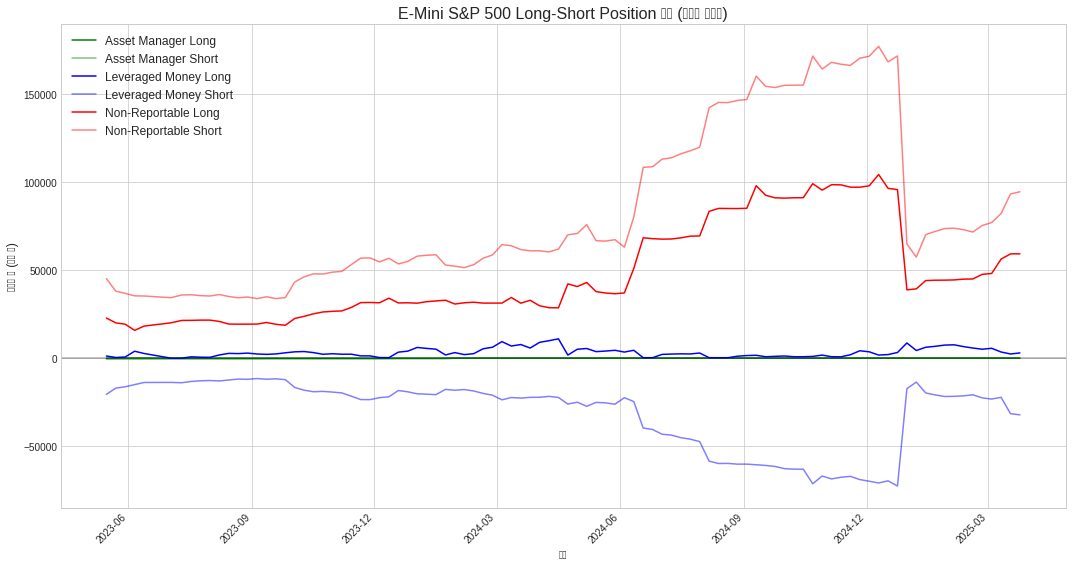

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

5 YEAR ERIS SWAP - CHICAGO BOARD OF TRADE
                                        Contract Name  Open Interest  \
Date                                                                   
2022-03-08  5 YEAR ERIS SWAP - CHICAGO BOARD OF TRADE        51777.0   
2022-03-01  5 YEAR ERIS SWAP - CHICAGO BOARD OF TRADE        51357.0   
2022-02-22  5 YEAR ERIS SWAP - CHICAGO BOARD OF TRADE        51829.0   
2022-02-15  5 YEAR ERIS SWAP - CHICAGO BOARD OF TRADE        52105.0   
2022-01-25  5 YEAR ERIS SWAP - CHICAGO BOARD OF TRADE        48425.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2022-03-08                 0.0                 -0.0                9773.0   
2022-03-01                 0.0                 -0.0                7214.0   
2022-02-22                 0.0                 -0.0                8042.0   
2022-02-15                 0.0                 -0.0                7

/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: U

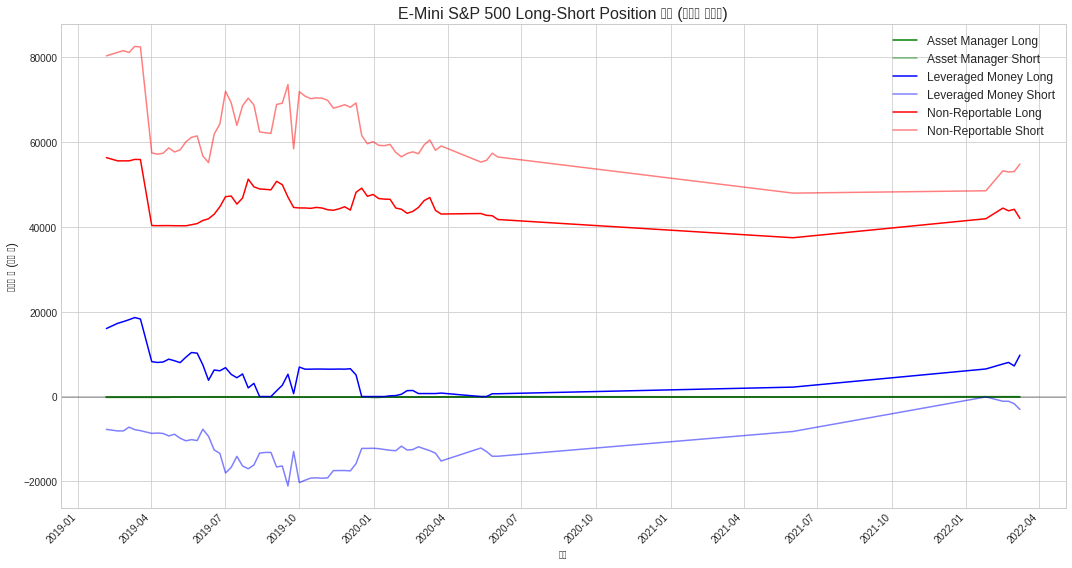

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

5-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF TRADE
                                                Contract Name  Open Interest  \
Date                                                                           
2022-02-01  5-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF ...      4019069.0   
2022-01-25  5-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF ...      3979852.0   
2022-01-18  5-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF ...      3826115.0   
2022-01-11  5-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF ...      3830246.0   
2022-01-04  5-YEAR U.S. TREASURY NOTES - CHICAGO BOARD OF ...      3702047.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2022-02-01           2169541.0           -1029661.0              390194.0   
2022-01-25           2145124.0            -999770.0              350694.0   
2022-01-18           2057115.0           -1045968.0              292697.0   
20

<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N

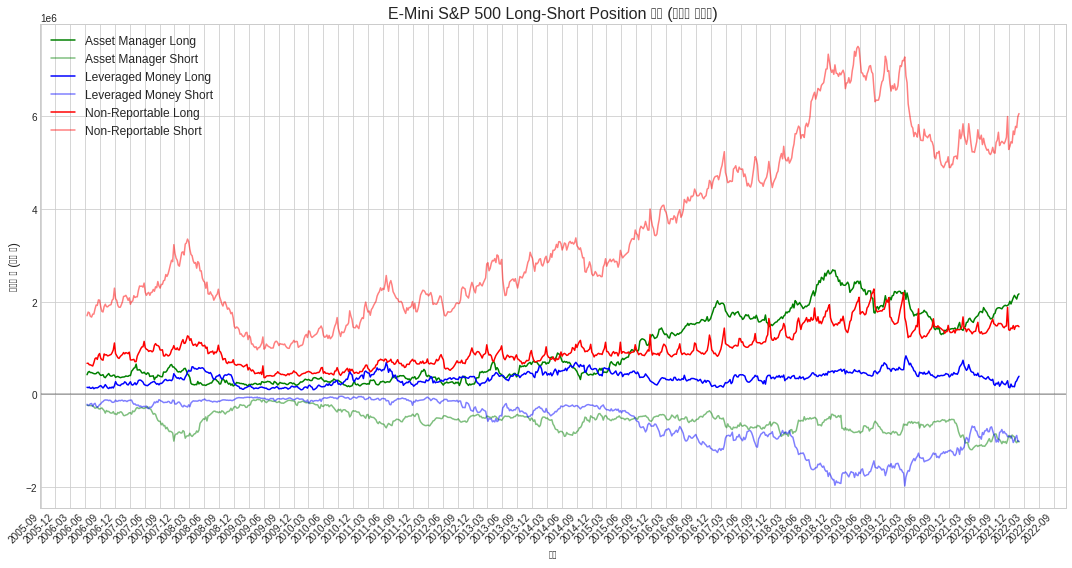

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

5-Year Eris Standard- Initial - ERIS FUTURES EXCHANGE
                                                Contract Name  Open Interest  \
Date                                                                           
2018-11-27  5-Year Eris Standard- Initial - ERIS FUTURES E...        19674.0   
2018-11-20  5-Year Eris Standard- Initial - ERIS FUTURES E...        76975.0   
2018-11-13  5-Year Eris Standard- Initial - ERIS FUTURES E...        76563.0   
2018-11-06  5-Year Eris Standard- Initial - ERIS FUTURES E...        76467.0   
2018-10-30  5-Year Eris Standard- Initial - ERIS FUTURES E...        75139.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2018-11-27               590.0                -85.0                4846.0   
2018-11-20               590.0                -25.0                7380.0   
2018-11-13               590.0                 -0.0                6976.0   


<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N

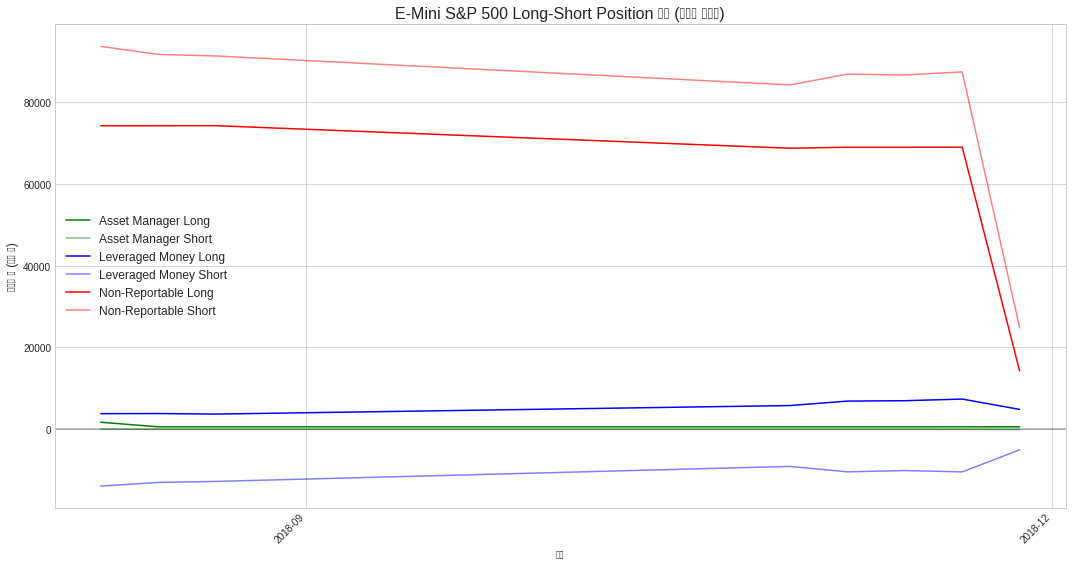

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])


ADJUSTED INT RATE S&P 500 TOTL - CHICAGO MERCANTILE EXCHANGE
                                                Contract Name  Open Interest  \
Date                                                                           
2025-03-25  ADJUSTED INT RATE S&P 500 TOTL - CHICAGO MERCA...       690810.0   
2025-03-18  ADJUSTED INT RATE S&P 500 TOTL - CHICAGO MERCA...       826742.0   
2025-03-11  ADJUSTED INT RATE S&P 500 TOTL - CHICAGO MERCA...       793095.0   
2025-03-04  ADJUSTED INT RATE S&P 500 TOTL - CHICAGO MERCA...       743611.0   
2025-02-25  ADJUSTED INT RATE S&P 500 TOTL - CHICAGO MERCA...       753539.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2025-03-25              1634.0             -76220.0              132479.0   
2025-03-18              1634.0             -76220.0              122842.0   
2025-03-11              1634.0             -76220.0              12015

<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Net'] = emini_data['Non-Reportable Long'] - emini_data['Non-Reportable Short']
<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from curr

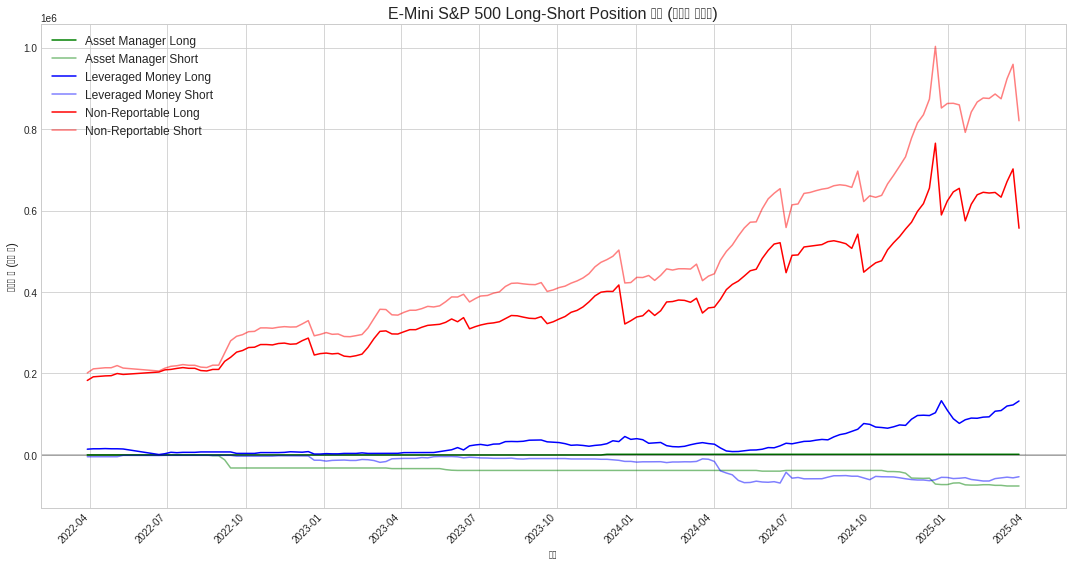

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

AUSTRALIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE
                                              Contract Name  Open Interest  \
Date                                                                         
2025-03-25  AUSTRALIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE       180087.0   
2025-03-18  AUSTRALIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE       180546.0   
2025-03-11  AUSTRALIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE       258738.0   
2025-03-04  AUSTRALIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE       202272.0   
2025-02-25  AUSTRALIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE       185971.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2025-03-25             46220.0             -84352.0               15664.0   
2025-03-18             47965.0             -84580.0               13309.0   
2025-03-11             53583.0             -91965.0               18600.0   
2025-03-04          

<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N

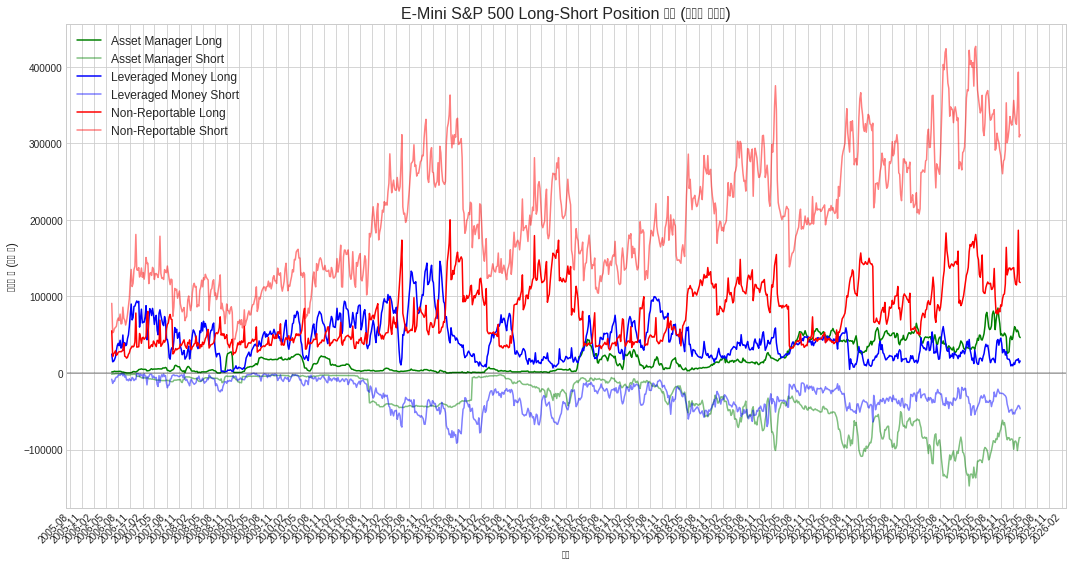

AVALANCHE - LMX LABS LLC
                       Contract Name  Open Interest  Asset Manager Long  \
Date                                                                      
2025-03-25  AVALANCHE - LMX LABS LLC         1342.0                 0.0   
2025-03-18  AVALANCHE - LMX LABS LLC         1179.0                 0.0   
2025-03-11  AVALANCHE - LMX LABS LLC         1195.0                 0.0   
2025-02-25  AVALANCHE - LMX LABS LLC         1402.0                 0.0   
2025-02-18  AVALANCHE - LMX LABS LLC         1886.0                 0.0   

            Asset Manager Short  Leveraged Money Long  Leveraged Money Short  \
Date                                                                           
2025-03-25                 -0.0                   0.0                  -99.0   
2025-03-18                 -0.0                 163.0                 -314.0   
2025-03-11                 -0.0                   0.0                 -271.0   
2025-02-25                 -0.0                  

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

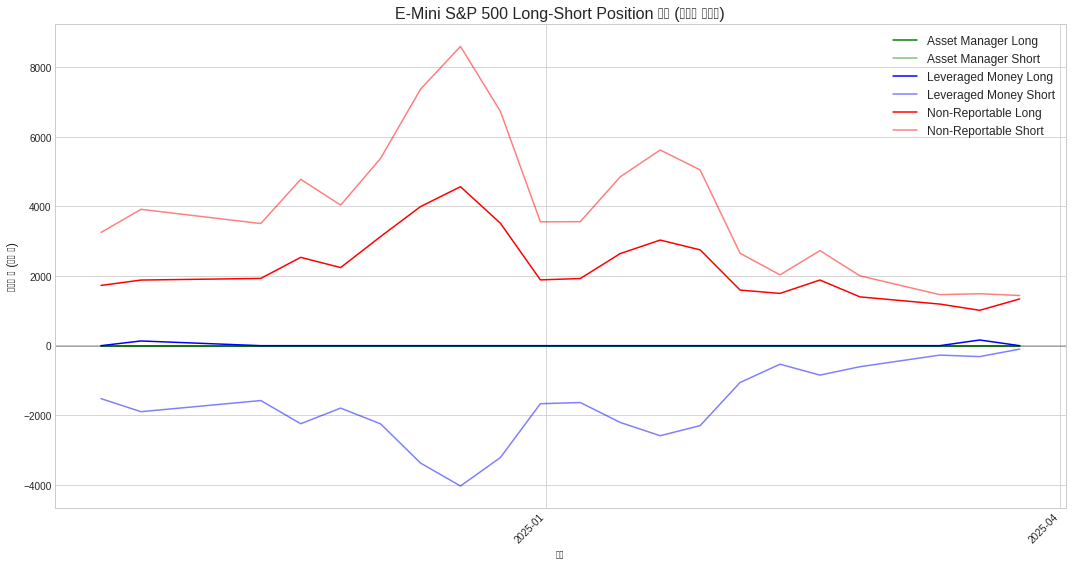

BBG COMMODITY - CHICAGO BOARD OF TRADE
                                     Contract Name  Open Interest  \
Date                                                                
2025-03-25  BBG COMMODITY - CHICAGO BOARD OF TRADE       220163.0   
2025-03-18  BBG COMMODITY - CHICAGO BOARD OF TRADE       231874.0   
2025-03-11  BBG COMMODITY - CHICAGO BOARD OF TRADE       211518.0   
2025-03-04  BBG COMMODITY - CHICAGO BOARD OF TRADE       206041.0   
2025-02-25  BBG COMMODITY - CHICAGO BOARD OF TRADE       208473.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2025-03-25             57328.0              -8503.0                4323.0   
2025-03-18             57142.0              -8503.0                4288.0   
2025-03-11             49237.0              -8503.0                4374.0   
2025-03-04             46136.0              -8503.0                4364.0   
2025-02-25     

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

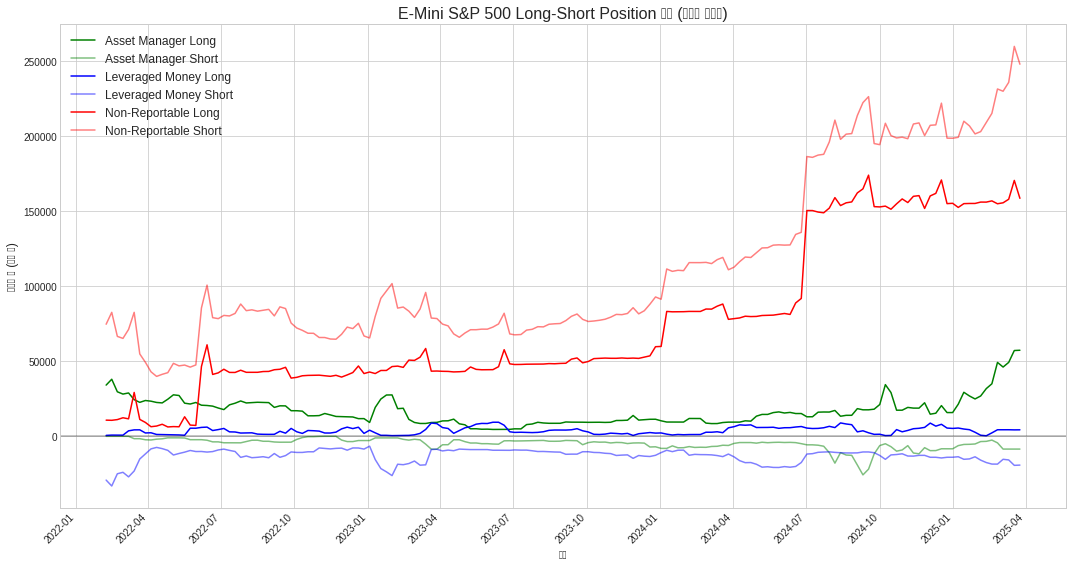

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

BITCOIN - CHICAGO MERCANTILE EXCHANGE
                                    Contract Name  Open Interest  \
Date                                                               
2025-03-25  BITCOIN - CHICAGO MERCANTILE EXCHANGE        29036.0   
2025-03-18  BITCOIN - CHICAGO MERCANTILE EXCHANGE        30213.0   
2025-03-11  BITCOIN - CHICAGO MERCANTILE EXCHANGE        28545.0   
2025-03-04  BITCOIN - CHICAGO MERCANTILE EXCHANGE        28209.0   
2025-02-25  BITCOIN - CHICAGO MERCANTILE EXCHANGE        32060.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2025-03-25              8235.0               -644.0                1825.0   
2025-03-18              7653.0               -693.0                3381.0   
2025-03-11              7930.0               -596.0                2547.0   
2025-03-04              8324.0               -433.0                2809.0   
2025-02-25             

<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N{HANGUL SYLLABLE YAG}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51088 (\N

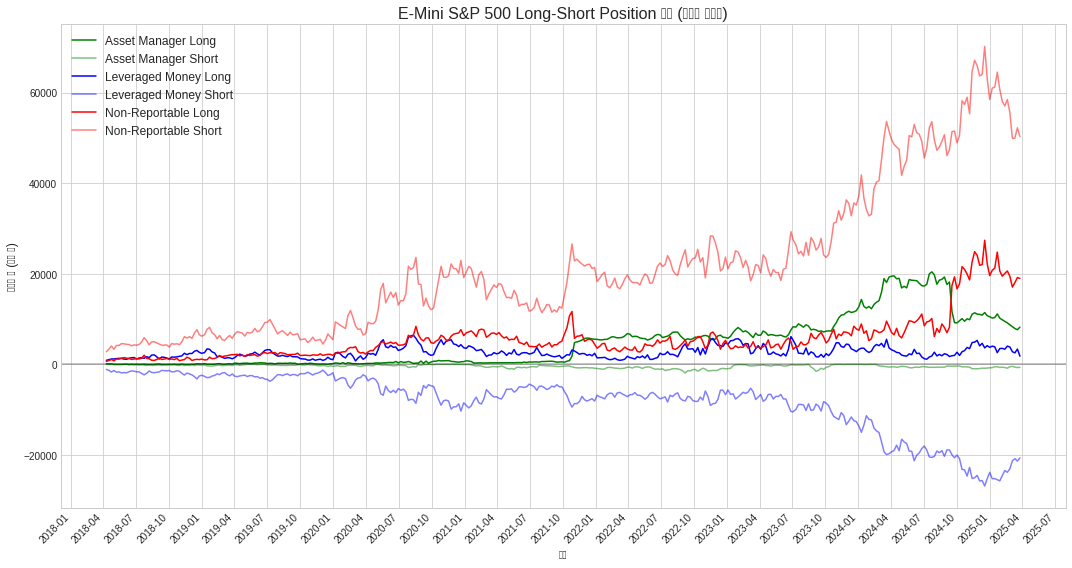

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

BITCOIN-USD - CBOE FUTURES EXCHANGE
                                  Contract Name  Open Interest  \
Date                                                             
2019-05-07  BITCOIN-USD - CBOE FUTURES EXCHANGE         2607.0   
2019-04-30  BITCOIN-USD - CBOE FUTURES EXCHANGE         2921.0   
2019-04-23  BITCOIN-USD - CBOE FUTURES EXCHANGE         2710.0   
2019-04-16  BITCOIN-USD - CBOE FUTURES EXCHANGE         2764.0   
2019-04-09  BITCOIN-USD - CBOE FUTURES EXCHANGE         3273.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2019-05-07                 0.0                 -0.0                 226.0   
2019-04-30                 0.0                 -0.0                 167.0   
2019-04-23                 0.0                 -0.0                 206.0   
2019-04-16                 0.0                 -0.0                 212.0   
2019-04-09                 0.0         

/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: U

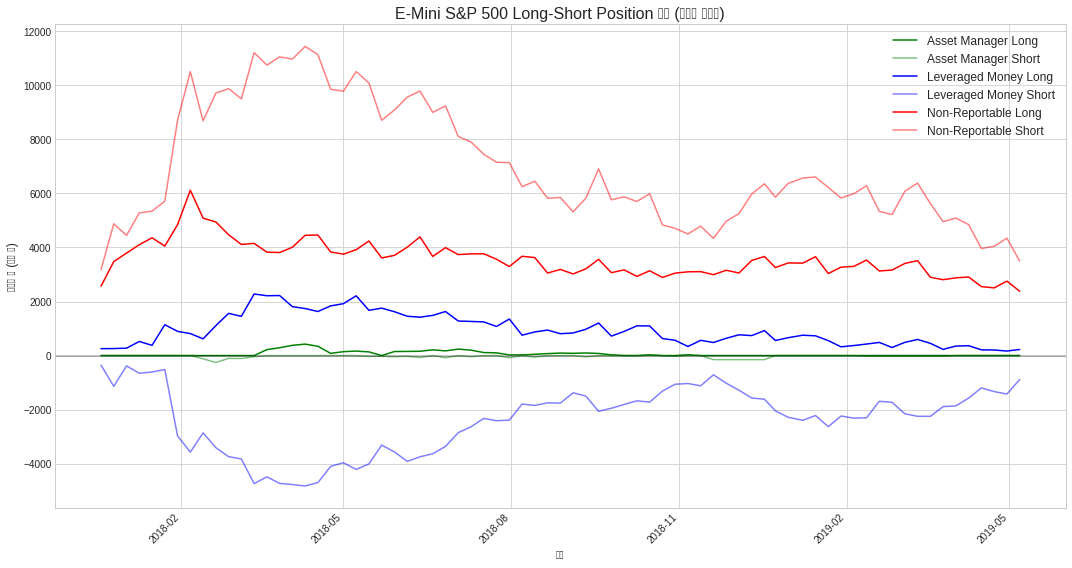

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

BLOOMBERG COMMODITY INDEX - CHICAGO BOARD OF TRADE
                                                Contract Name  Open Interest  \
Date                                                                           
2022-02-01  BLOOMBERG COMMODITY INDEX - CHICAGO BOARD OF T...        48941.0   
2022-01-25  BLOOMBERG COMMODITY INDEX - CHICAGO BOARD OF T...        49419.0   
2022-01-18  BLOOMBERG COMMODITY INDEX - CHICAGO BOARD OF T...        48271.0   
2022-01-11  BLOOMBERG COMMODITY INDEX - CHICAGO BOARD OF T...        53734.0   
2022-01-04  BLOOMBERG COMMODITY INDEX - CHICAGO BOARD OF T...        48172.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2022-02-01             37985.0                 -0.0                 445.0   
2022-01-25             36132.0              -2732.0                 578.0   
2022-01-18             35071.0                 -0.0                 466.0   
202

/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/youngjins/miniconda3/envs/belief_pred/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: U

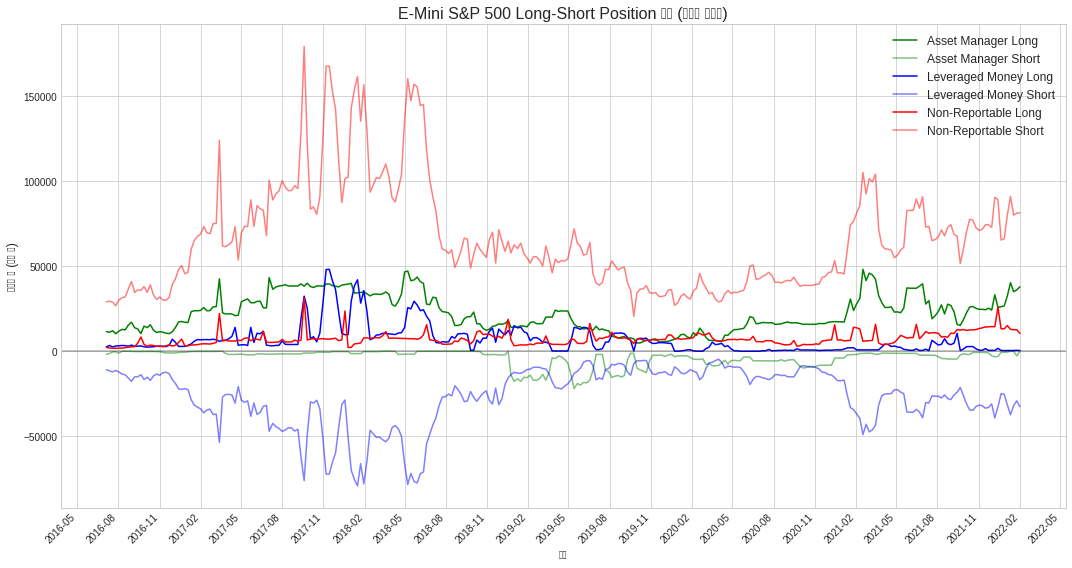

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

BRAZILIAN REAL - CHICAGO MERCANTILE EXCHANGE
                                           Contract Name  Open Interest  \
Date                                                                      
2025-03-25  BRAZILIAN REAL - CHICAGO MERCANTILE EXCHANGE       109079.0   
2025-03-18  BRAZILIAN REAL - CHICAGO MERCANTILE EXCHANGE        99549.0   
2025-03-11  BRAZILIAN REAL - CHICAGO MERCANTILE EXCHANGE       102759.0   
2025-03-04  BRAZILIAN REAL - CHICAGO MERCANTILE EXCHANGE       105980.0   
2025-02-25  BRAZILIAN REAL - CHICAGO MERCANTILE EXCHANGE       152424.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2025-03-25             79711.0              -7265.0               11885.0   
2025-03-18             66103.0              -8314.0               11869.0   
2025-03-11             79747.0             -10621.0               13607.0   
2025-03-04             88319.0              

<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N

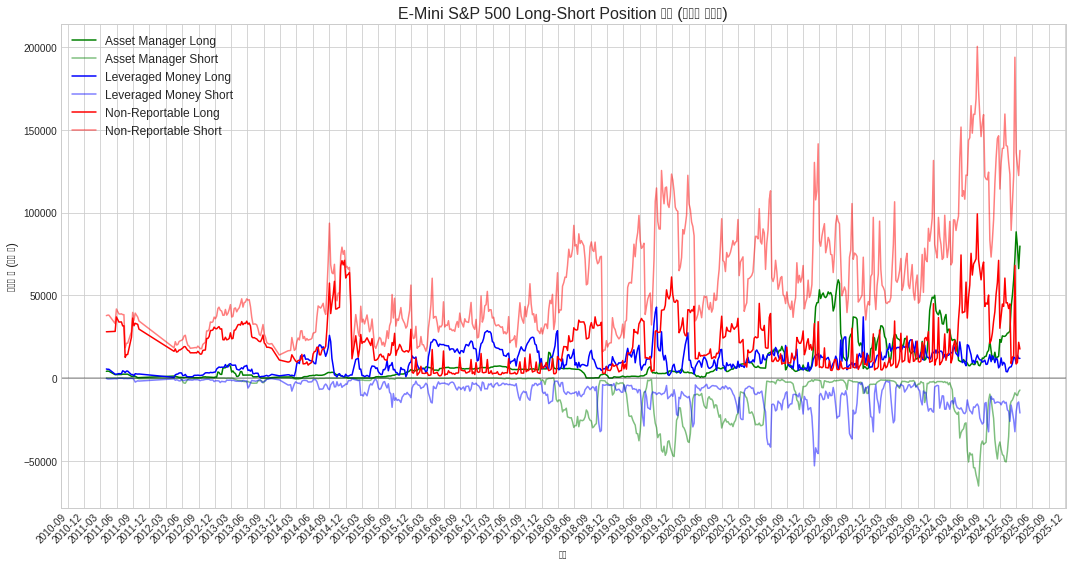

BRITISH POUND - CHICAGO MERCANTILE EXCHANGE
                                          Contract Name  Open Interest  \
Date                                                                     
2025-03-25  BRITISH POUND - CHICAGO MERCANTILE EXCHANGE       191212.0   
2025-03-18  BRITISH POUND - CHICAGO MERCANTILE EXCHANGE       180841.0   
2025-03-11  BRITISH POUND - CHICAGO MERCANTILE EXCHANGE       248457.0   
2025-03-04  BRITISH POUND - CHICAGO MERCANTILE EXCHANGE       200634.0   
2025-02-25  BRITISH POUND - CHICAGO MERCANTILE EXCHANGE       200468.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2025-03-25             67411.0             -72801.0               71377.0   
2025-03-18             60369.0             -73497.0               67268.0   
2025-03-11             51007.0             -76459.0               61074.0   
2025-03-04             41378.0             -86017.0 

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

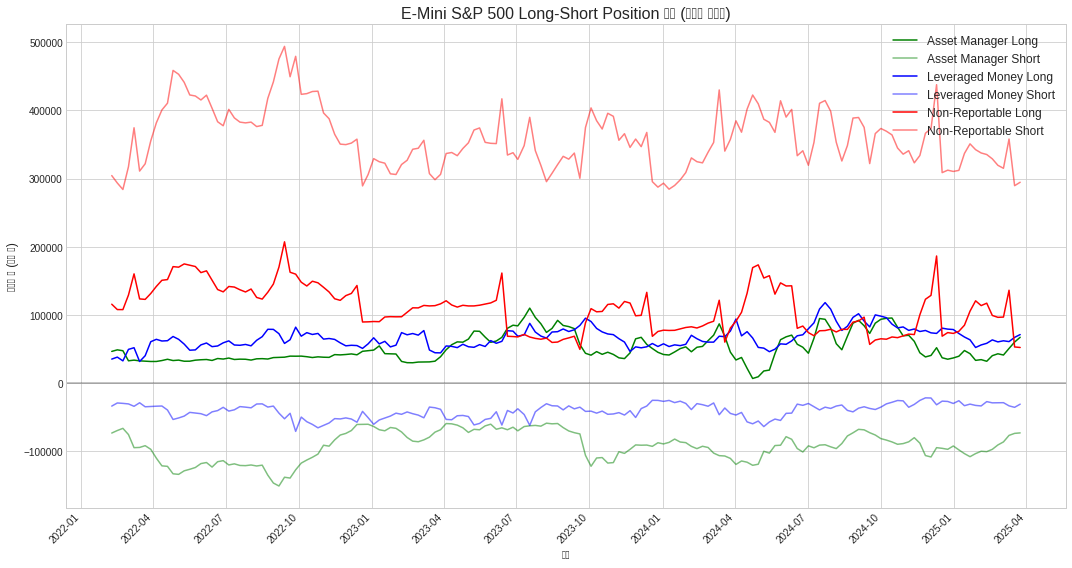

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

BRITISH POUND STERLING - CHICAGO MERCANTILE EXCHANGE
                                                Contract Name  Open Interest  \
Date                                                                           
2022-02-01  BRITISH POUND STERLING - CHICAGO MERCANTILE EX...       184007.0   
2022-01-25  BRITISH POUND STERLING - CHICAGO MERCANTILE EX...       182040.0   
2022-01-18  BRITISH POUND STERLING - CHICAGO MERCANTILE EX...       183234.0   
2022-01-11  BRITISH POUND STERLING - CHICAGO MERCANTILE EX...       200493.0   
2022-01-04  BRITISH POUND STERLING - CHICAGO MERCANTILE EX...       200007.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2022-02-01             36175.0             -79449.0               32333.0   
2022-01-25             39204.0             -71102.0               34125.0   
2022-01-18             46072.0             -64869.0               31636.0   
2

<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N

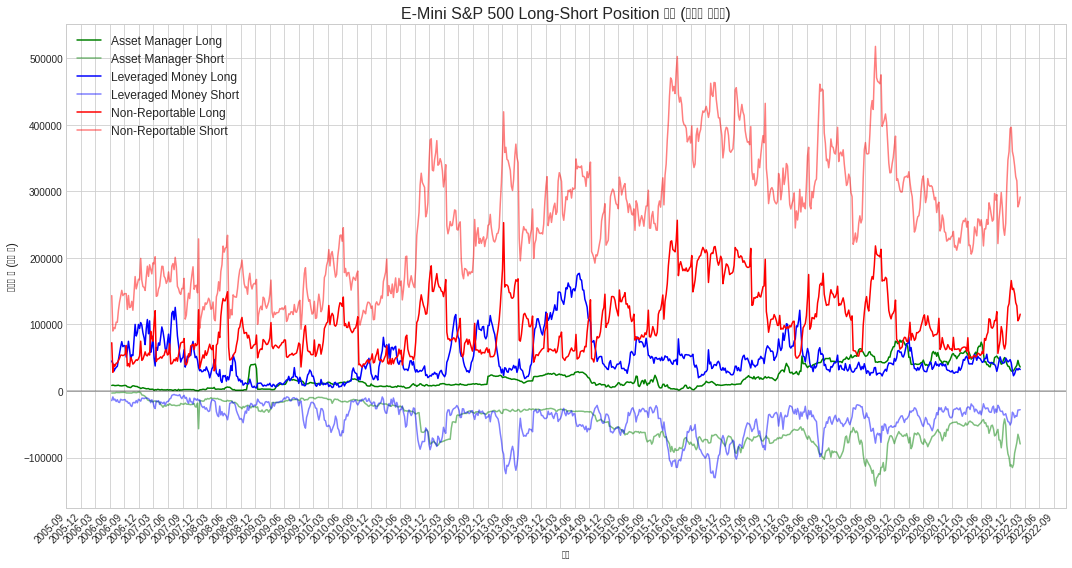

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE
                                            Contract Name  Open Interest  \
Date                                                                       
2025-03-25  CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE       281126.0   
2025-03-18  CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE       347932.0   
2025-03-11  CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE       339922.0   
2025-03-04  CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE       340218.0   
2025-02-25  CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE       319493.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2025-03-25             32203.0            -161425.0               17877.0   
2025-03-18             31120.0            -169724.0               10823.0   
2025-03-11             30511.0            -177603.0                6946.0   
2025-03-04             31569.0      

<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N

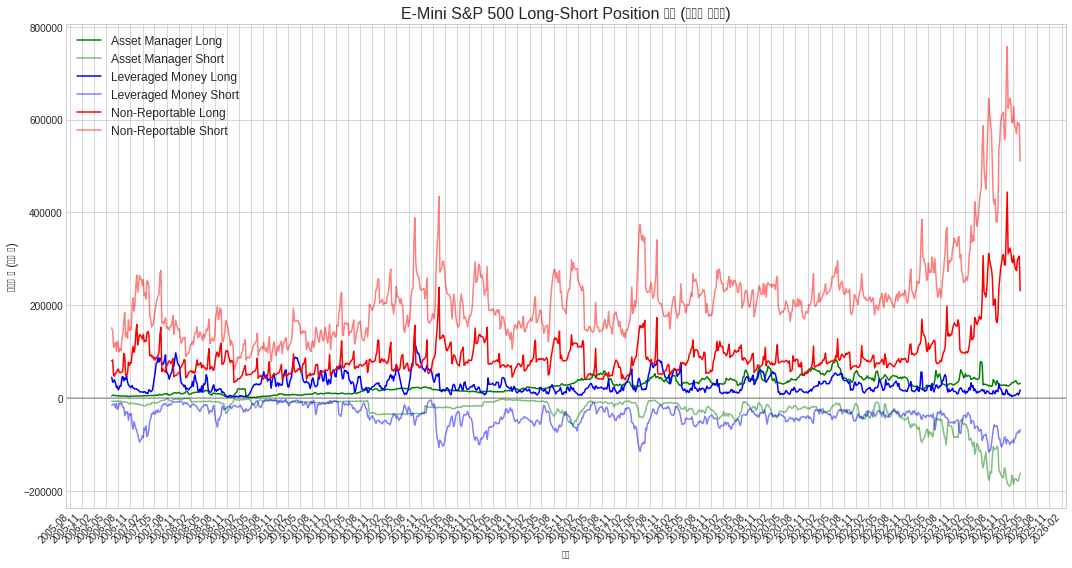

CHAINLINK - LMX LABS LLC
                       Contract Name  Open Interest  Asset Manager Long  \
Date                                                                      
2025-02-25  CHAINLINK - LMX LABS LLC         2058.0                 0.0   
2025-02-18  CHAINLINK - LMX LABS LLC         2190.0                 0.0   
2025-02-11  CHAINLINK - LMX LABS LLC         2093.0                 0.0   
2025-02-04  CHAINLINK - LMX LABS LLC         1578.0                 0.0   
2025-01-28  CHAINLINK - LMX LABS LLC         1795.0                 0.0   

            Asset Manager Short  Leveraged Money Long  Leveraged Money Short  \
Date                                                                           
2025-02-25                 -0.0                   0.0                -1782.0   
2025-02-18                 -0.0                   0.0                -1702.0   
2025-02-11                 -0.0                   0.0                -1570.0   
2025-02-04                 -0.0                  

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

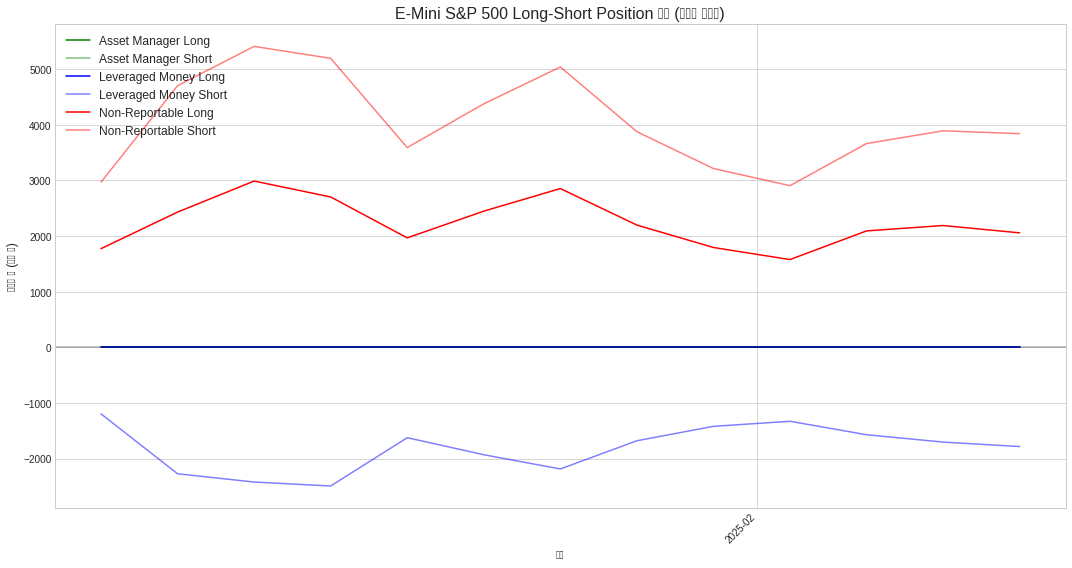

CHINESE RENMINBI-HK (CNH) - CHICAGO MERCANTILE EXCHANGE
                                                Contract Name  Open Interest  \
Date                                                                           
2022-05-10  CHINESE RENMINBI-HK (CNH) - CHICAGO MERCANTILE...         7284.0   
2022-05-03  CHINESE RENMINBI-HK (CNH) - CHICAGO MERCANTILE...         8416.0   
2022-04-26  CHINESE RENMINBI-HK (CNH) - CHICAGO MERCANTILE...         8464.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2022-05-10                 0.0               -100.0                 875.0   
2022-05-03                 0.0               -200.0                2166.0   
2022-04-26                 0.0               -250.0                2322.0   

            Leveraged Money Short  Open Interest, Change  \
Date                                                       
2022-05-10                -6671.0    

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

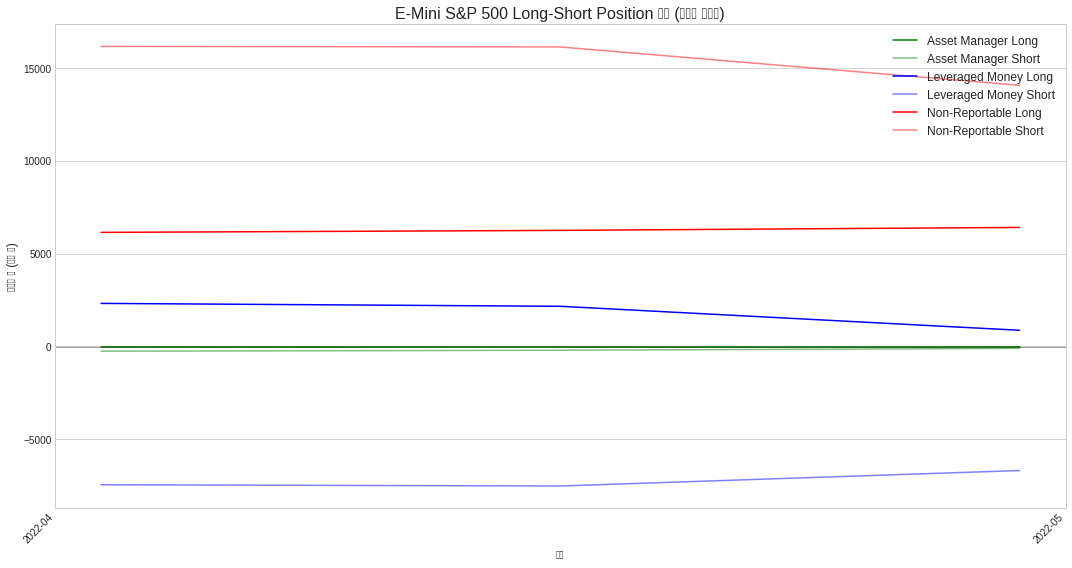

<ipython-input-3-789585640295>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
<ipython-input-3-789585640295>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
<ipython-input-3-789585640295>:24: SettingWithCopyWarning: 
A value is 

DJIA Consolidated - CHICAGO BOARD OF TRADE
                                         Contract Name  Open Interest  \
Date                                                                    
2025-03-25  DJIA Consolidated - CHICAGO BOARD OF TRADE        74443.0   
2025-03-18  DJIA Consolidated - CHICAGO BOARD OF TRADE        94597.0   
2025-03-11  DJIA Consolidated - CHICAGO BOARD OF TRADE        77307.0   
2025-03-04  DJIA Consolidated - CHICAGO BOARD OF TRADE        77647.0   
2025-02-25  DJIA Consolidated - CHICAGO BOARD OF TRADE        81664.0   

            Asset Manager Long  Asset Manager Short  Leveraged Money Long  \
Date                                                                        
2025-03-25             15816.0             -14037.0                7699.0   
2025-03-18             10425.0             -14081.0               17073.0   
2025-03-11             11116.0             -15591.0               16440.0   
2025-03-04             10855.0             -11715.0         

<ipython-input-3-789585640295>:50: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
<ipython-input-3-789585640295>:50: UserWarning: Glyph 50557 (\N

KeyboardInterrupt: 

In [3]:
# 필요한 COT 데이터 가져오기
cot = CommitmentsOfTraders(report_type='traders_in_financial_futures_fut')

# 모든 contract에 대해서 계산하기
available_contracts = cot.financial_report()

for contract in available_contracts:
    print(contract)
    
    # report 가져오기 
    emini_data = cot.report(contract)

    # 데이터 구조 확인
    print(emini_data.head()) 
    
    # 데이터 전처리
    # 1. 자산 운용사 (Asset Manager)
    # 2. 대형 투기자 (Leveraged Money - 헤지펀드, 대형 투기자로 분류됨)
    # 3. 비-보고 대상 (Non-Reportable - 직접 계산 필요)

    # 비-보고 대상 계산 (전체 오픈 인터레스트에서 보고된 포지션을 뺀 값)
    emini_data['Non-Reportable Long'] = emini_data['Open Interest'] - (emini_data['Asset Manager Long'] + emini_data['Leveraged Money Long'])
    emini_data['Non-Reportable Short'] = emini_data['Open Interest'] - (emini_data['Asset Manager Short'] + emini_data['Leveraged Money Short'])
    emini_data['Non-Reportable Net'] = emini_data['Non-Reportable Long'] - emini_data['Non-Reportable Short']

    # 추가 분석: 세 그룹의 Long short position 비교
    plt.figure(figsize=(15, 8))
    
    # Asset Manager (초록색)
    plt.plot(emini_data.index, emini_data['Asset Manager Long'], color='green', alpha=1, label='Asset Manager Long')
    plt.plot(emini_data.index, emini_data['Asset Manager Short'], color='green', alpha=0.5, label='Asset Manager Short')
    
    # Leveraged Money (파랑색)
    plt.plot(emini_data.index, emini_data['Leveraged Money Long'], color='blue', alpha=1, label='Leveraged Money Long')
    plt.plot(emini_data.index, emini_data['Leveraged Money Short'], color='blue', alpha=0.5, label='Leveraged Money Short')
    
    # Non-Reportable (빨간색)
    plt.plot(emini_data.index, emini_data['Non-Reportable Long'], color='red', alpha=1, label='Non-Reportable Long')
    plt.plot(emini_data.index, emini_data['Non-Reportable Short'], color='red', alpha=0.5, label='Non-Reportable Short')
    
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.title('E-Mini S&P 500 Long-Short Position 비교 (투자자 유형별)', fontsize=16)
    plt.xlabel('날짜', fontsize=12)
    plt.ylabel('포지션 수 (계약 수)', fontsize=12)
    plt.grid(True)
    plt.legend(fontsize=12)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()